# Notebook 11 - EDA Visualization


This notebook pulls together the main chart types used across the earlier notebooks into one place, using Matplotlib and Seaborn. Every chart here is chosen for a reason, not just to fill the notebook - each one is followed by what it shows and what it means for the data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("custumer.csv")
sns.set_style("whitegrid")
df.head()

,CustomerID,Age,Gender,TenureYears,MonthlyCharges,TotalCharges,ContractType,InternetService,PaymentMethod,SeniorCitizen,SupportCalls,StreamingService,PaperlessBilling,Churn
0,CUST00001,56.0,Female,0,20.41,131.92,One year,DSL,Bank transfer,No,3,No,Yes,Yes
1,CUST00002,69.0,Male,9,21.10,2394.45,Two year,DSL,Credit card,Yes,1,Yes,No,No
2,CUST00003,46.0,Female,3,61.66,2755.45,Two year,DSL,Bank transfer,No,3,Yes,No,No
3,CUST00004,32.0,Male,8,35.50,3796.58,Month-to-month,No,Credit card,No,2,No,No,No
4,CUST00005,60.0,Male,9,86.45,10188.80,Two year,Fiber optic,Electronic check,Yes,3,No,Yes,Yes


## 1. Histogram

### Why this chart
A histogram groups a numerical column into bins and shows how many rows fall into each bin. It's the fastest way to see the overall shape of a single number column - whether it's spread evenly, skewed, or has multiple peaks.

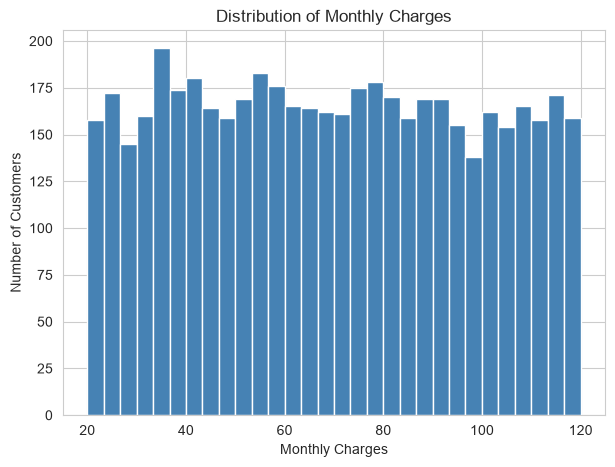

In [3]:
plt.figure(figsize=(7,5))
plt.hist(df['MonthlyCharges'], bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.show()

**Interpretation:** MonthlyCharges is spread across a wide range with no single sharp peak, and it looks close to a multi-modal shape rather than a simple bell curve, likely because it depends on multiple services being combined (internet + streaming etc).

**Insight:** Because the shape isn't a clean normal distribution, scaling methods that assume normality may not be the best fit for this column later on.

## 2. Box Plot

### Why this chart
A box plot shows the median, the interquartile range (the middle 50% of the data), and marks points outside 1.5x the IQR as outliers. It's the standard chart for spotting outliers and comparing spread across groups in one picture.

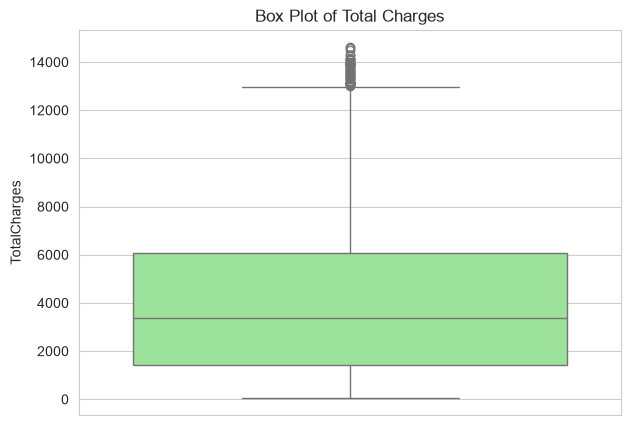

In [4]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, y='TotalCharges', color='lightgreen')
plt.title('Box Plot of Total Charges')
plt.show()

**Interpretation:** TotalCharges has a long upper range, with the box (middle 50%) sitting fairly low and a tail stretching upward - customers with long tenure and high monthly charges naturally build up large TotalCharges values, so this is an expected pattern rather than bad data.

**Insight:** TotalCharges is right-skewed, which lines up with what a log transform is typically used to fix before modeling.

## 3. Bar Chart

### Why this chart
A bar chart compares totals or averages across categories. It's used here to compare average MonthlyCharges across the different ContractType groups.

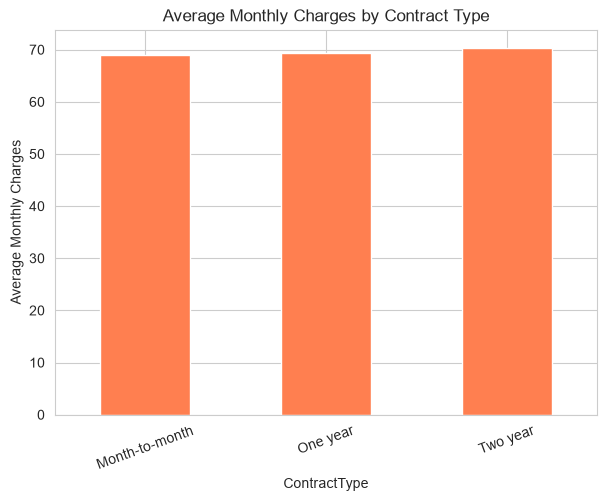

In [5]:
avg_charges = df.groupby('ContractType')['MonthlyCharges'].mean().sort_values()

plt.figure(figsize=(7,5))
avg_charges.plot(kind='bar', color='coral')
plt.title('Average Monthly Charges by Contract Type')
plt.ylabel('Average Monthly Charges')
plt.xticks(rotation=20)
plt.show()

**Interpretation:** Average monthly charges are fairly close across the three contract types, with only a small difference between them.

**Insight:** Contract type on its own doesn't explain pricing differences much - the pricing likely depends more on which services (internet type, streaming) a customer has picked.

## 4. Count Plot

### Why this chart
A count plot is a bar chart specifically for categorical data, showing how many rows fall into each category. Used here to see the balance across PaymentMethod.

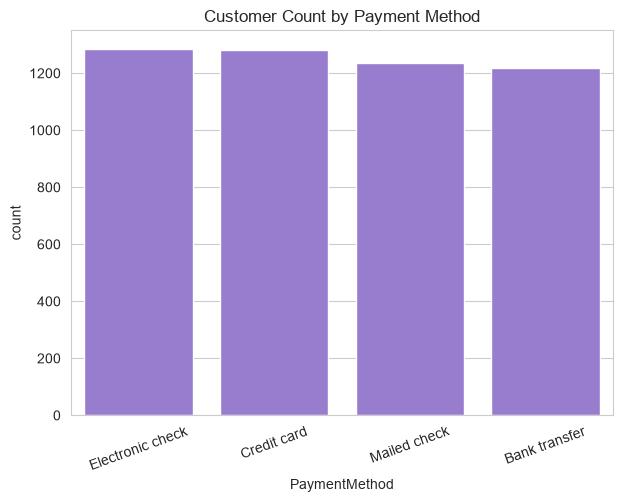

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='PaymentMethod', order=df['PaymentMethod'].value_counts().index, color='mediumpurple')
plt.title('Customer Count by Payment Method')
plt.xticks(rotation=20)
plt.show()

**Interpretation:** The four payment methods are close to evenly split, with Electronic check slightly ahead of the others.

**Insight:** No payment method dominates the data, so this column won't need any rebalancing before use.

## 5. Scatter Plot

### Why this chart
A scatter plot shows the relationship between two numerical columns, point by point. Used here to check whether TenureYears and TotalCharges move together, which they should if TotalCharges accumulates over time.

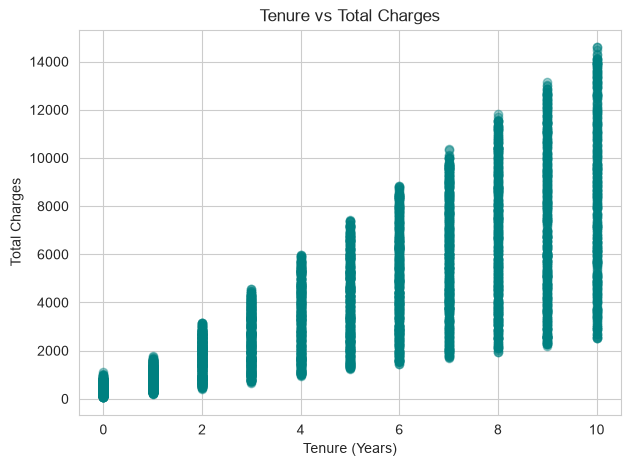

In [7]:
plt.figure(figsize=(7,5))
plt.scatter(df['TenureYears'], df['TotalCharges'], alpha=0.4, color='teal')
plt.title('Tenure vs Total Charges')
plt.xlabel('Tenure (Years)')
plt.ylabel('Total Charges')
plt.show()

**Interpretation:** There's a clear upward trend - customers with more years of tenure generally have higher total charges, which makes sense since charges build up month after month.

**Insight:** TenureYears and TotalCharges are related, so using both together in a model could introduce redundancy (multicollinearity), which is worth checking in the Multivariate notebook.

## 6. Line Plot

### Why this chart
A line plot is best for showing a trend across an ordered variable. Here TenureYears is a natural ordered variable, so we use it to see how average MonthlyCharges changes as tenure increases.

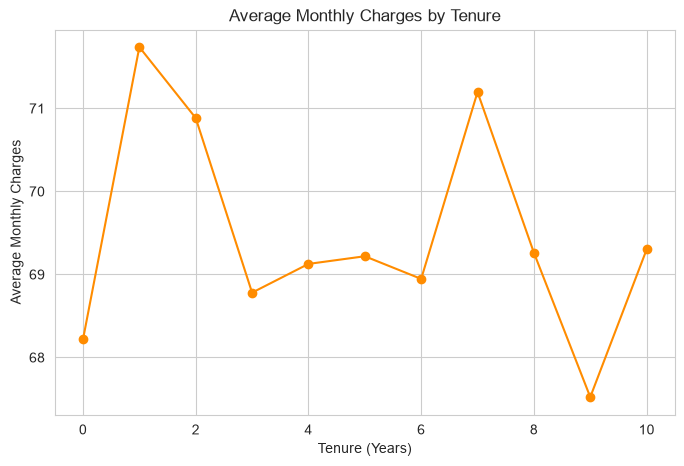

In [9]:
avg_by_tenure = df.groupby('TenureYears')['MonthlyCharges'].mean()

plt.figure(figsize=(8,5))
plt.plot(avg_by_tenure.index, avg_by_tenure.values, marker='o', color='darkorange')
plt.title('Average Monthly Charges by Tenure')
plt.xlabel('Tenure (Years)')
plt.ylabel('Average Monthly Charges')
plt.show()

**Interpretation:** Average MonthlyCharges stays roughly flat across different tenure years, without a strong rising or falling trend.

**Insight:** New and long-time customers are being charged similarly per month on average, so tenure by itself is not driving the pricing.

## 7. Violin Plot

### Why this chart
A violin plot is like a box plot but also shows the shape of the distribution (through width), making it useful for comparing both spread and shape of a numeric column across categories.

C:\Users\HP\AppData\Local\Temp\ipykernel_9480\2541357791.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


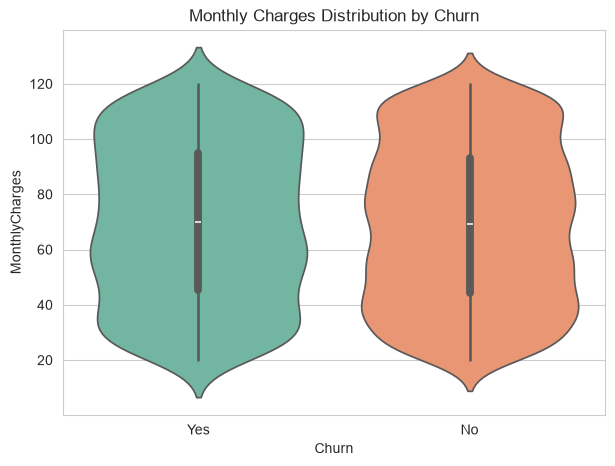

In [10]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges Distribution by Churn')
plt.show()

**Interpretation:** The Churn = Yes group is a bit wider toward higher MonthlyCharges values compared to Churn = No, suggesting churned customers skew slightly toward paying more per month.

**Insight:** This supports what we saw in Notebook 10 - MonthlyCharges is a column worth including as a predictor since its shape differs by class, not just its average.

## 8. Pair Plot

### Why this chart
A pair plot shows scatter plots for every pair of numerical columns at once, with the target used as a color hue. It's a fast way to spot which feature pairs separate the classes well, without writing a scatter plot for every combination manually.

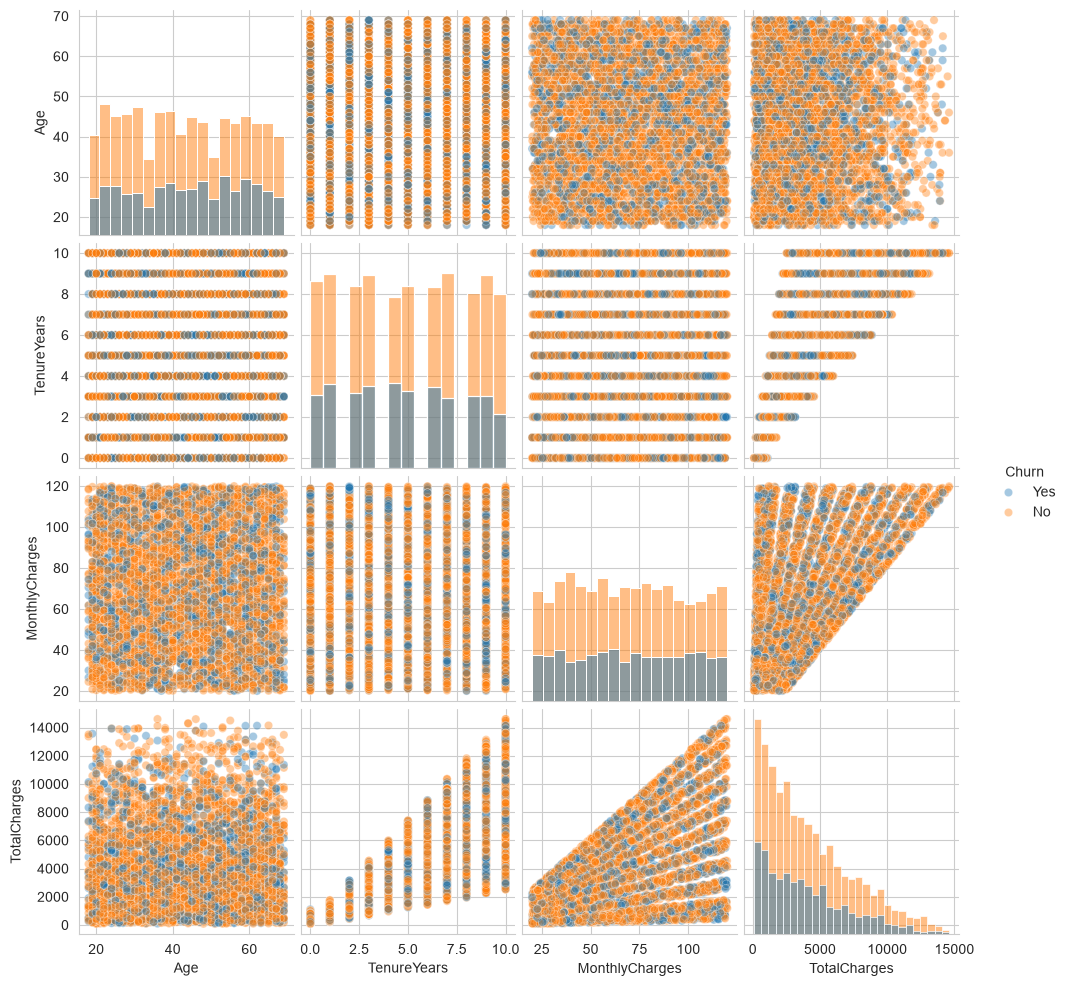

In [12]:
pair_cols = ['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'Churn']
sns.pairplot(df[pair_cols], hue='Churn', diag_kind='hist', plot_kws={'alpha':0.4})
plt.show()

**Interpretation:** No single pair of features cleanly separates Churn = Yes from Churn = No into two distinct clusters, but TenureYears shows the most visible separation - the orange (churned) points lean toward lower tenure across most panels.

**Insight:** No individual pair of features is a perfect separator on its own, which suggests a model will need to combine several features together rather than relying on just one or two.

## 9. Heatmap

### Why this chart
A heatmap visualizes a correlation matrix with color, making it much faster to spot strong or weak relationships between numerical columns than reading a table of numbers.

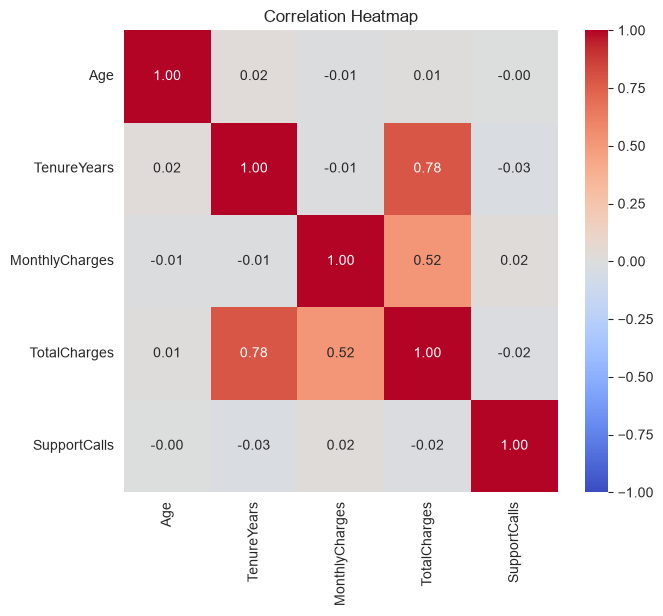

In [13]:
num_cols = ['Age', 'TenureYears', 'MonthlyCharges', 'TotalCharges', 'SupportCalls']
corr = df[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

**Interpretation:** TenureYears and TotalCharges have the strongest positive correlation in the dataset, which matches the scatter plot we saw earlier. The rest of the numerical columns show weak correlations with each other.

**Insight:** Because TenureYears and TotalCharges are strongly correlated, keeping both as separate features in a model may not add much extra information - this is a candidate for feature selection or combining later.

## 10. Distribution Plot

### Why this chart
A distribution plot (histogram with a smoothed density curve) shows the shape of a numerical column more clearly than a plain histogram, especially for spotting skewness.

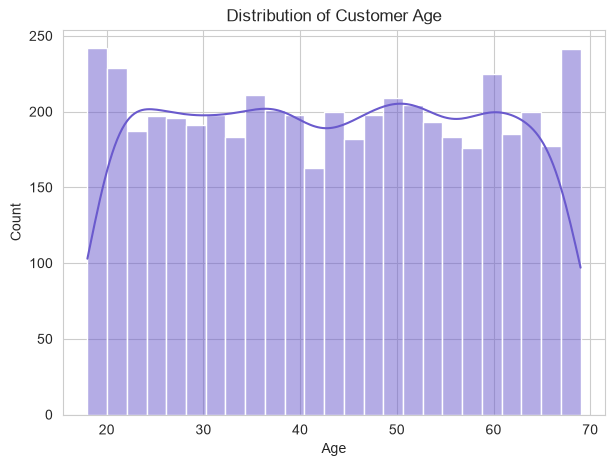

In [14]:
plt.figure(figsize=(7,5))
sns.histplot(df['Age'], kde=True, color='slateblue', bins=25)
plt.title('Distribution of Customer Age')
plt.show()

**Interpretation:** Age looks close to evenly spread across the adult range with a fairly flat density curve, without a strong peak on one end.

**Insight:** Age doesn't need any transformation before modeling since it doesn't show meaningful skew.

### AI/ML Relevance
Together these charts point to a few practical takeaways for modeling: TotalCharges is right-skewed and may need a transform, TenureYears and TotalCharges are correlated enough to cause redundancy, and MonthlyCharges plus TenureYears both show a visible relationship with Churn and look like useful predictors.